In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def gaussian(x, loc, s):
    return (1 / np.sqrt(2 * np.pi * s**2) *
            np.exp(-(x - loc)**2 / (2 * s**2)))

# Raw (non-Gaussian) conductivity data of LIG (S/cm)
population = rng.lognormal(mean=np.log(180), sigma=0.25, size=200_000)

sample_size = 500
n_means = 100

means = []
for _ in range(n_means):
    sample = rng.choice(population, size=sample_size, replace=False)
    means.append(sample.mean())

means = np.array(means)

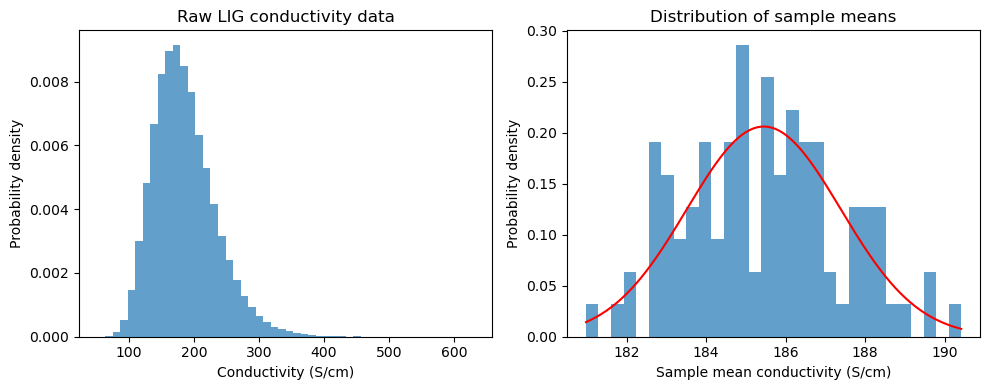

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

# Left panel: raw conductivity distribution
ax[0].hist(population, bins=50, density=True, alpha=0.7)
ax[0].set_xlabel("Conductivity (S/cm)")
ax[0].set_ylabel("Probability density")
ax[0].set_title("Raw LIG conductivity data")

# Right panel: distribution of sample means
ax[1].hist(means, bins=30, density=True, alpha=0.7)

x = np.linspace(means.min(), means.max(), 300)
ax[1].plot(x, gaussian(x, means.mean(), means.std()), 'r-')

ax[1].set_xlabel("Sample mean conductivity (S/cm)")
ax[1].set_ylabel("Probability density")
ax[1].set_title("Distribution of sample means")

plt.tight_layout()


In [3]:
#Interpretation
#The left panel shows the distribution of individual LIG conductivity measurements.
#The distribution is clearly non-Gaussian and right-skewed, which is typical for transport properties influenced by percolation paths, defects, and local inhomogeneities.
#The right panel shows the distribution of sample means obtained by averaging 𝑛=50
#n=50 conductivity measurements. Despite the non-Gaussian nature of the raw data, 
#the distribution of the means closely follows a Gaussian shape, as confirmed by the superimposed normal distribution.
#This striking contrast visually demonstrates the central limit theorem: regardless of
#the underlying distribution of the data, the distribution of sample means approaches a normal distribution
#when the sample size is sufficiently large and measurements are independent.